<div style="border:3px solid #1f6fb2;border-radius:10px;padding:52px 44px;text-align:center;background:linear-gradient(160deg,#f8fbff 0%,#e4f0fc 100%);margin-bottom:8px;">
  <div style="font-size:56px;font-weight:900;color:#1f6fb2;letter-spacing:4px;margin-bottom:18px;font-family:sans-serif;">ICU SEPSIS RL</div>
  <div style="font-size:20px;font-weight:700;color:#1a3a5c;margin-bottom:8px;">Clinical Treatment Optimisation: Sepsis ICU Management</div>
  <div style="font-size:15px;font-style:italic;color:#4a6a8a;margin-bottom:38px;">Configuration A – Tabular Reinforcement Learning</div>
  <hr style="border:none;border-top:2px solid #1f6fb2;width:48%;margin:0 auto 28px auto;">
  <div style="font-size:14px;font-weight:600;color:#1a3a5c;margin-bottom:6px;">Student 1 &nbsp;|&nbsp; Student 2 &nbsp;|&nbsp; Student 3 &nbsp;|&nbsp; Student 4 &nbsp;|&nbsp; Student 5</div>
  <div style="font-size:13px;font-style:italic;color:#6a8aaa;">NOVA IMS – Master in Data Science &amp; Advanced Analytics – Reinforcement Learning – May 2026</div>
</div>

<font color='#2f94d7' size=6>**TABLE OF CONTENTS**</font> <a class="anchor" id='toc'></a>

- [1. Project Overview](#1)
- [2. Set Up and Import Libraries](#2)
- [3. Environment Exploration](#3)
  - [3.1 State Space](#3_1)
  - [3.2 Transition Dynamics](#3_2)
  - [3.3 Reward Structure](#3_3)
  - [3.4 Random Baseline](#3_4)
  - [3.5 Feature-Outcome Relationship](#3_5)
  - [3.6 Action Space](#3_6)
- [4. Dyna-Q with Prioritized Sweeping and Shaping](#4)
  - [4.1 Rationale and Architecture](#4_1)
  - [4.2 Implementation](#4_2)
  - [4.3 Results Evaluation - Baseline](#4_3)
  - [4.4 Hyperparameter Tuning - Optuna](#4_4)
  - [4.5 Results Evaluation - Optimised](#4_5)
- [5. Q-Learning with Learning Rate Decay and Shaping](#5)
  - [5.1 Rationale and Architecture](#5_1)
  - [5.2 Implementation](#5_2)
  - [5.3 Results Evaluation - Baseline](#5_3)
  - [5.4 Hyperparameter Tuning - Optuna](#5_4)
  - [5.5 Results Evaluation - Optimised](#5_5)
- [6. Results and Visualizations](#6)
- [7. Comparative Analysis](#7)
- [8. Creative Extension: Clinical Decision Support Analysis](#8)
  - [8.1 V-PI as a Clinical Acuity Score](#8_1)
  - [8.2 Treatment Strategy by Patient Severity](#8_2)
  - [8.3 Comparison of Learned Feature Importance](#8_3)


# <font color='#2f94d7' size=6>**1. Project Overview**</font> <a class="anchor" id="1"></a>

[Back to TOC](#toc)

Configuration A applies **tabular reinforcement learning** to the ICU-Sepsis-v2 environment,
a discrete MDP derived from real MIMIC-III patient data. The state space consists of 716
discrete states (714 clinical plus 2 terminal: survived and died), and the action space
contains 25 treatment combinations (5 vasopressor levels x 5 IV fluid dose levels).

**Fixed configuration:** sofa_bias = 5.0, lam = 0.02 (as defined in env_setup.py).

**Implementation pattern (applied to every algorithm):**

1. Define a reusable training function `train_ALGO(hyperparameters, n_episodes, verbose)`
2. Optuna calls this function 50 times with different hyperparameter combinations (50k episodes each)
3. The best combination is used for the final training run (full episodes, verbose output)

**Primary evaluation metrics:**
- **Survival Rate:** policy evaluation over 1000 episodes after training
- **Learning Curve:** rolling 500-episode survival rate during training, showing the speed
  at which each algorithm learns to improve patient outcomes over time


# <font color='#2f94d7' size=6>**2. Set Up and Import Libraries**</font> <a class="anchor" id="2"></a>

[Back to TOC](#toc)

In [5]:
!pip install icu-sepsis stable-baselines3 torch gymnasium optuna shap scikit-learn


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, time, heapq
import optuna
from sklearn.ensemble import GradientBoostingRegressor
import shap

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'
SEED = 42
np.random.seed(SEED)

from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM, make_sepsis_env,
)
from envs.continuous_sepsis_env import ContinuousICUSepsisEnv, FEATURE_NAMES

print(f'ICU-Sepsis-v2  |  States: {N_STATES}  |  Actions: {N_ACTIONS}')
print(f'Fixed config   |  sofa_bias={SOFA_BIAS}, lam={LAM}')
print(f'Optuna version : {optuna.__version__}')

ICU-Sepsis-v2  |  States: 716  |  Actions: 25
Fixed config   |  sofa_bias=5.0, lam=0.02
Optuna version : 4.8.0


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [7]:
import functions_ConfigA as fa
from functions_ConfigA import (
    # Colour palette
    H_COL, B0, B1, B2, B3, B4, B5, B6, REF_RAND, REF_PI,
    C_PI, C_DQ, C_ES, C_QL, C_SAR, C_DQL, C_MC, C_WS,
    PLOTS_DIR,
    # Utilities
    smooth, silent_eval, evaluate_policy, make_env,
    make_optuna_callback,
    # Plots — generic
    plot_results, plot_optuna_history,
    plot_learning_curve, plot_survival_rate,
    # Plots — PI specific
    plot_pi_results,
    # Optuna runners
    run_optuna, run_optuna_dynaq, run_optuna_qlearning,
    # Training functions
    train_dynaq_ps, train_qlearning,
    # Creative Extension
    clinical_acuity_analysis,
    treatment_strategy_analysis,
    shap_comparison,
)

S = N_STATES; A = N_ACTIONS
N_TRIALS   = 30
TRIAL_EPS  = 60_000 
TRIAL_EVAL = 300
SEED = fa.SEED

print(f'functions_ConfigA loaded.')
print(f'Config: sofa_bias={SOFA_BIAS}, lam={LAM}')
print(f'Optuna: {N_TRIALS} trials x {TRIAL_EPS:,} episodes x {TRIAL_EVAL} eval')

functions_ConfigA loaded.
Config: sofa_bias=5.0, lam=0.02
Optuna: 30 trials x 60,000 episodes x 300 eval


# <font color='#2f94d7' size=6>**3. Environment Exploration**</font> <a class="anchor" id="3"></a>

[Back to TOC](#toc)

In [9]:
env = make_sepsis_env()
raw = env.unwrapped
P_mat = raw._tx_mat.copy()
R_mat = (raw._r_mat * raw._tx_mat).sum(axis=2)
sofa_scores = raw._sofa_scores.flatten()
d0   = raw._d_0.copy()
cont_env = ContinuousICUSepsisEnv(params=env)
cluster_centers = cont_env._cluster_centers.copy()
env.close(); cont_env.close()
print(f'P_mat: {P_mat.shape}  |  R_mat: {R_mat.shape}  |  Clusters: {cluster_centers.shape}')
print(f'SOFA range: [{sofa_scores[:S-2].min():.1f}, {sofa_scores[:S-2].max():.1f}]')

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
P_mat: (716, 25, 716)  |  R_mat: (716, 25)  |  Clusters: (716, 47)
SOFA range: [0.0, 18.0]


## <font color='#2f94d7' size=6>**3.1 State Space**</font> <a class="anchor" id="3_1"></a>

[Back to TOC](#toc)

714 clinical states derived from MIMIC-III patient clustering, plus 2 terminal absorbing
states (STATE_DIED=713, STATE_SURVIVED=714). Each state corresponds to a cluster of patients
with similar physiological profiles. The SOFA score (Sequential Organ Failure Assessment)
characterises clinical severity per state. With sofa_bias=5.0, the initial distribution
is weighted toward sicker patients (higher SOFA scores).


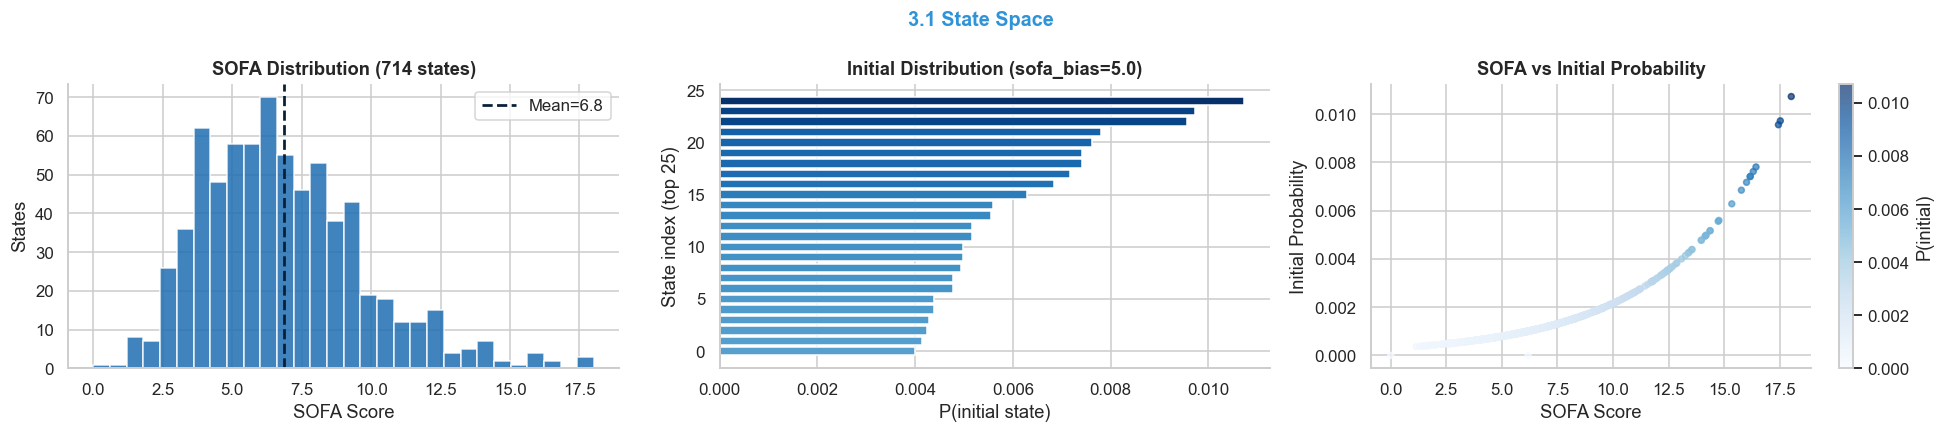

Active initial states: 712 / 714
Weighted mean SOFA   : 9.02


In [11]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.1 State Space',fontsize=13,fontweight='bold',color=H_COL)
sofa_cl=sofa_scores[:S-2]; d0_cl=d0[:S-2]
axes[0].hist(sofa_cl,bins=30,color=B2,edgecolor='white',alpha=0.85)
axes[0].axvline(np.mean(sofa_cl),color=B0,ls='--',lw=1.8,label=f'Mean={np.mean(sofa_cl):.1f}')
axes[0].set_xlabel('SOFA Score'); axes[0].set_ylabel('States')
axes[0].set_title('SOFA Distribution (714 states)',fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
top_idx=np.argsort(d0_cl)[-25:]
axes[1].barh(range(25),d0_cl[top_idx],
             color=[plt.cm.Blues(0.3+0.7*v/d0_cl[top_idx].max()) for v in d0_cl[top_idx]],
             edgecolor='white')
axes[1].set_xlabel('P(initial state)'); axes[1].set_ylabel('State index (top 25)')
axes[1].set_title(f'Initial Distribution (sofa_bias={SOFA_BIAS})',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
sc=axes[2].scatter(sofa_cl,d0_cl,c=d0_cl,cmap='Blues',s=15,alpha=0.7)
plt.colorbar(sc,ax=axes[2],label='P(initial)')
axes[2].set_xlabel('SOFA Score'); axes[2].set_ylabel('Initial Probability')
axes[2].set_title('SOFA vs Initial Probability',fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_1.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Active initial states: {np.sum(d0_cl>0)} / {S-2}')
print(f'Weighted mean SOFA   : {np.average(sofa_cl,weights=d0_cl):.2f}')

## <font color='#2f94d7' size=6>**3.2 Transition Dynamics**</font> <a class="anchor" id="3_2"></a>

[Back to TOC](#toc)

P(s'|s,a) has shape (716,25,716). Derived from real trajectories, most transitions are
stochastic. The branching factor (reachable next states per action) and the probability of
reaching terminal states are key characteristics that determine algorithm difficulty.


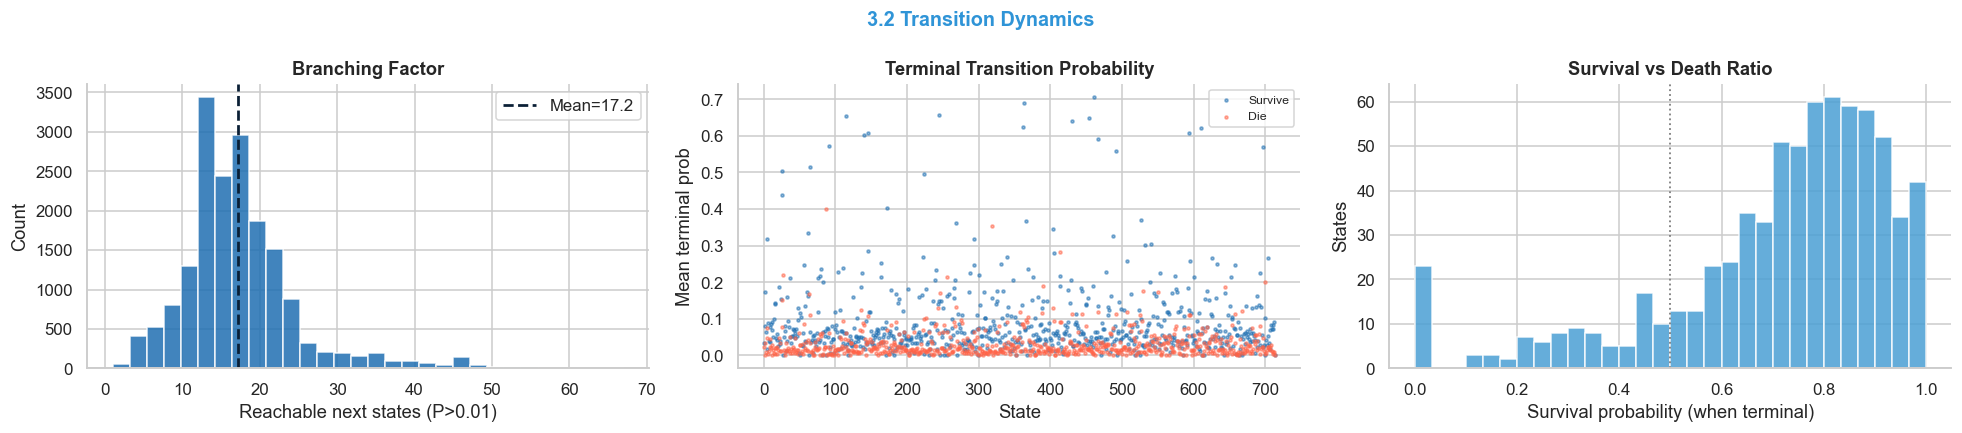

Sparsity: 88.0%  |  Mean branching: 17.2


In [13]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.2 Transition Dynamics',fontsize=13,fontweight='bold',color=H_COL)
P_cl=P_mat[:S-2]; branching=(P_cl>0.01).sum(axis=2)
axes[0].hist(branching.flatten(),bins=30,color=B2,edgecolor='white',alpha=0.85)
axes[0].axvline(np.mean(branching),color=B0,ls='--',lw=1.8,label=f'Mean={np.mean(branching):.1f}')
axes[0].set_xlabel('Reachable next states (P>0.01)'); axes[0].set_ylabel('Count')
axes[0].set_title('Branching Factor',fontweight='bold')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)
p_surv=P_cl[:,:,STATE_SURVIVED].mean(axis=1); p_die=P_cl[:,:,STATE_DIED].mean(axis=1)
axes[1].scatter(range(S-2),p_surv,s=4,color=B2,alpha=0.5,label='Survive')
axes[1].scatter(range(S-2),p_die,s=4,color='tomato',alpha=0.5,label='Die')
axes[1].set_xlabel('State'); axes[1].set_ylabel('Mean terminal prob')
axes[1].set_title('Terminal Transition Probability',fontweight='bold')
axes[1].legend(fontsize=8); axes[1].spines[['top','right']].set_visible(False)
surv_ratio=np.where((p_surv+p_die)>0,p_surv/(p_surv+p_die+1e-9),0.5)
axes[2].hist(surv_ratio,bins=30,color=B3,edgecolor='white',alpha=0.85)
axes[2].axvline(0.5,color='grey',ls=':',lw=1.2)
axes[2].set_xlabel('Survival probability (when terminal)'); axes[2].set_ylabel('States')
axes[2].set_title('Survival vs Death Ratio',fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_2.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Sparsity: {(1-(P_cl>0).mean())*100:.1f}%  |  Mean branching: {np.mean(branching):.1f}')

## <font color='#2f94d7' size=6>**3.3 Reward Structure**</font> <a class="anchor" id="3_3"></a>

[Back to TOC](#toc)

The reward is terminal-only and sparse: +1.0 at survival, 0.0 at death, 0.0 at all
intermediate steps. With lam=0.02, a treatment intensity penalty is subtracted at each
step. This extreme sparsity is the primary challenge for model-free credit assignment.


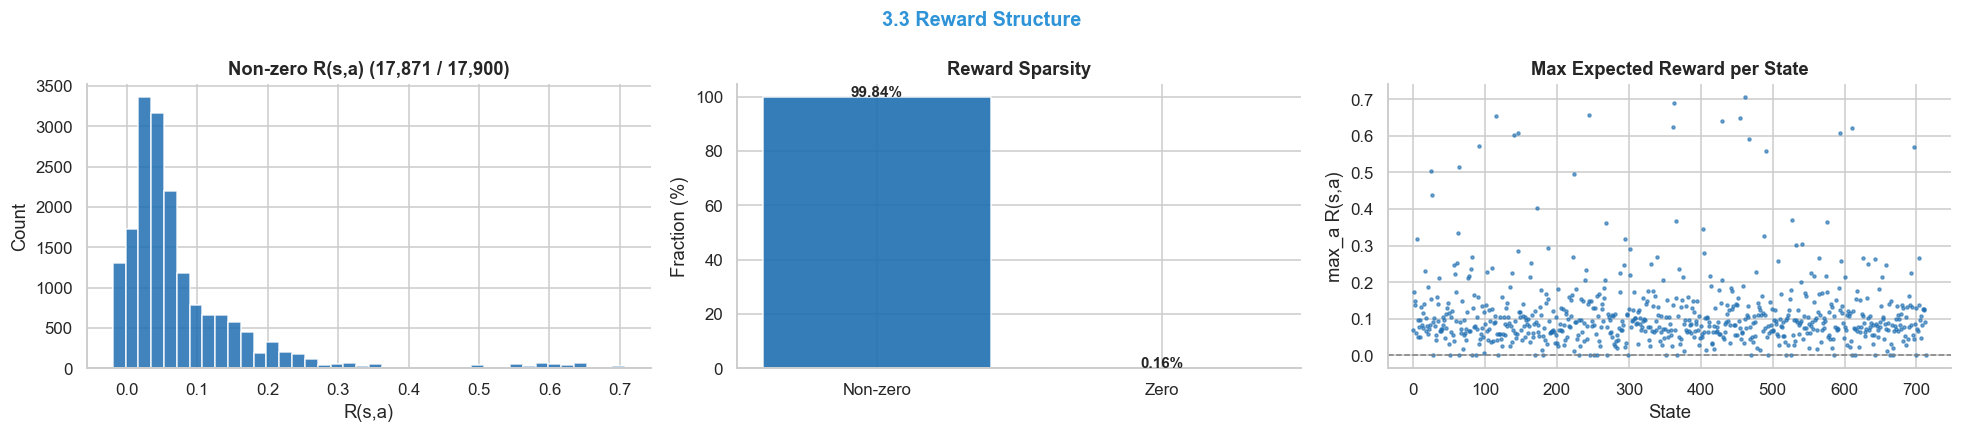

Non-zero R: 99.838%  |  R range: [-0.0200, 0.7076]


In [15]:
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.3 Reward Structure',fontsize=13,fontweight='bold',color=H_COL)
nz=R_mat[R_mat!=0].flatten()
axes[0].hist(nz,bins=40,color=B2,edgecolor='white',alpha=0.85)
axes[0].set_xlabel('R(s,a)'); axes[0].set_ylabel('Count')
axes[0].set_title(f'Non-zero R(s,a) ({len(nz):,} / {R_mat.size:,})',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
nzf=np.mean(R_mat!=0)*100
axes[1].bar(['Non-zero','Zero'],[nzf,100-nzf],color=[B2,B6],edgecolor='white',alpha=0.9)
axes[1].set_ylabel('Fraction (%)'); axes[1].set_title('Reward Sparsity',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for i,v in enumerate([nzf,100-nzf]):
    axes[1].text(i,v+0.2,f'{v:.2f}%',ha='center',fontsize=10,fontweight='bold')
axes[2].scatter(range(S-2),R_mat[:S-2].max(axis=1),s=4,color=B2,alpha=0.6)
axes[2].axhline(0,color='grey',ls='--',lw=1.0)
axes[2].set_xlabel('State'); axes[2].set_ylabel('max_a R(s,a)')
axes[2].set_title('Max Expected Reward per State',fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_3.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Non-zero R: {nzf:.3f}%  |  R range: [{R_mat.min():.4f}, {R_mat.max():.4f}]')

## <font color='#2f94d7' size=6>**3.4 Random Baseline**</font> <a class="anchor" id="3_4"></a>

[Back to TOC](#toc)

1000 episodes with a uniformly random policy establish the lower bound for all learned
policies and the baseline for the survival rate and learning curve comparisons.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


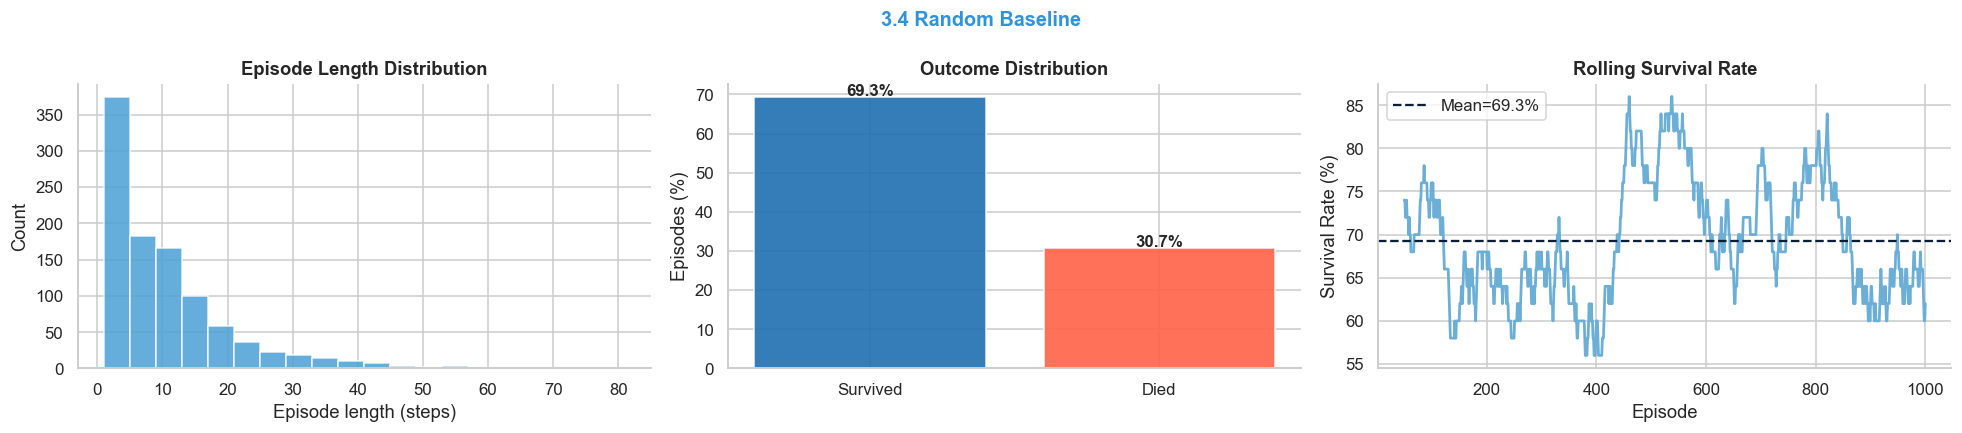

Random baseline: 69.3% +/- 2.9%  |  Mean length: 10.1 steps
Random baseline: 69.3% | mean return: 0.5932


In [17]:
np.random.seed(SEED); env_r=make_sepsis_env(); rand_returns,rand_lengths=[],[]
for ep in range(1000):
    obs,_=env_r.reset(seed=np.random.randint(100_000)); total_r,steps,done=0.0,0,False
    while not done:
        obs,r,te,tr,_=env_r.step(env_r.action_space.sample()); total_r+=r; steps+=1; done=te or tr
    rand_returns.append(total_r); rand_lengths.append(steps)
env_r.close()
rand_returns=np.array(rand_returns); rand_lengths=np.array(rand_lengths)
rand_survival=float(np.mean(rand_returns>0))*100
rand_surv_ci =1.96*np.sqrt((rand_survival/100)*(1-rand_survival/100)/1000)*100
fig,axes=plt.subplots(1,3,figsize=(18,4))
fig.suptitle('3.4 Random Baseline',fontsize=13,fontweight='bold',color=H_COL)
axes[0].hist(rand_lengths,bins=20,color=B3,edgecolor='white',alpha=0.85)
axes[0].set_xlabel('Episode length (steps)'); axes[0].set_ylabel('Count')
axes[0].set_title('Episode Length Distribution',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
axes[1].bar(['Survived','Died'],[rand_survival,100-rand_survival],
            color=[B2,'tomato'],edgecolor='white',alpha=0.9)
axes[1].set_ylabel('Episodes (%)'); axes[1].set_title('Outcome Distribution',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
for i,v in enumerate([rand_survival,100-rand_survival]):
    axes[1].text(i,v+0.5,f'{v:.1f}%',ha='center',fontsize=11,fontweight='bold')
roll=smooth((rand_returns>0).astype(float)*100,50)
axes[2].plot(np.arange(50,1001),roll,color=REF_RAND,lw=1.8)
axes[2].axhline(rand_survival,color=B0,ls='--',lw=1.5,label=f'Mean={rand_survival:.1f}%')
axes[2].set_xlabel('Episode'); axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_title('Rolling Survival Rate',fontweight='bold')
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_4.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Random baseline: {rand_survival:.1f}% +/- {rand_surv_ci:.1f}%  |  Mean length: {np.mean(rand_lengths):.1f} steps')

rand_mean_ret = float(np.mean(rand_returns))
print(f'Random baseline: {rand_survival:.1f}% | mean return: {rand_mean_ret:.4f}')

## <font color='#2f94d7' size=6>**3.5 Feature-Outcome Relationship**</font> <a class="anchor" id="3_5"></a>

[Back to TOC](#toc)

Each of the 714 clinical states corresponds to a cluster centre in the 47-dimensional
physiological feature space shared with Config B. The correlation of each feature with
V_PI(s) (the survival probability under optimal treatment) reveals which physiological
variables are most associated with patient outcomes, providing a clinical interpretation
of the state space that bridges both configurations.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


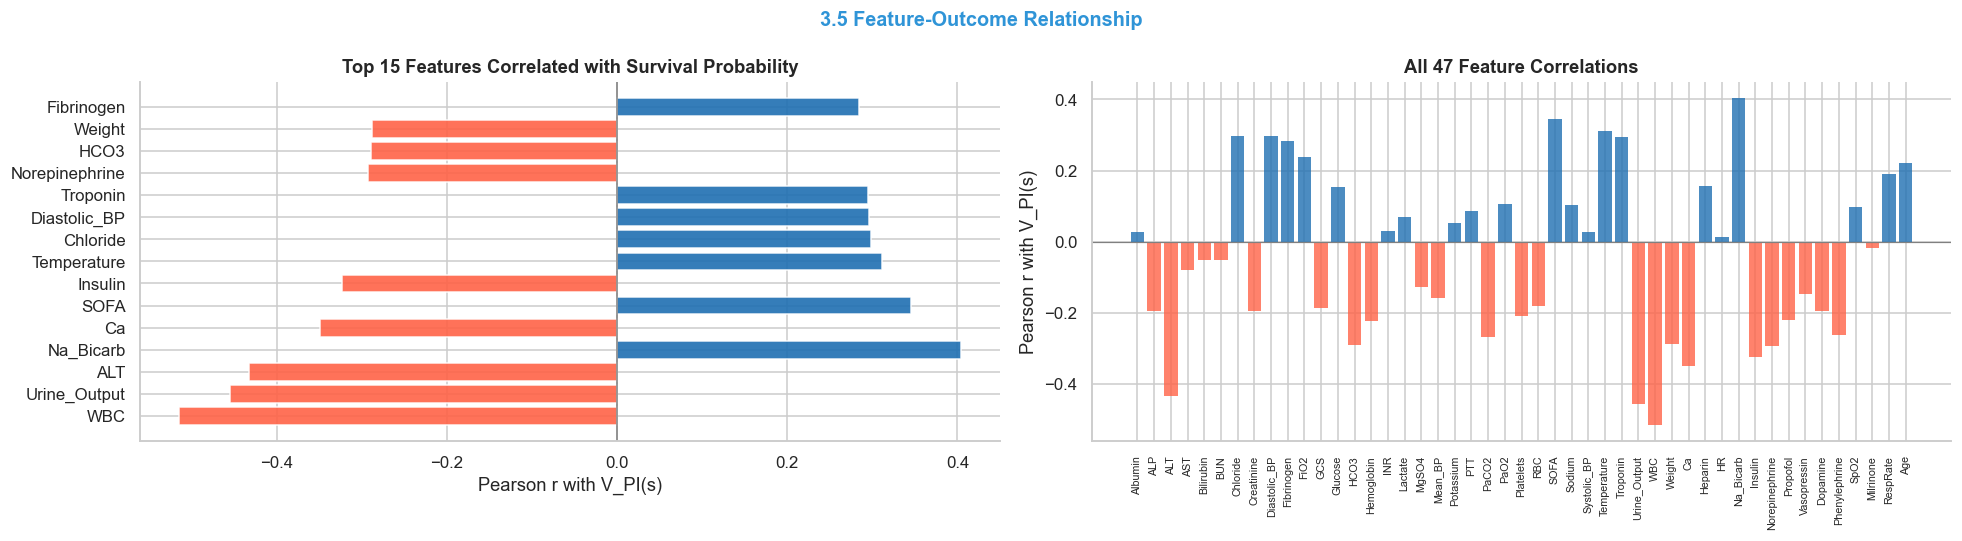

Top 5 positive: ['Na_Bicarb']
Top 5 negative: ['WBC', 'Urine_Output', 'ALT', 'Ca', 'Insulin']


In [19]:
env0=make_sepsis_env(); raw0=env0.unwrapped
P0=raw0._tx_mat.copy(); R0=(raw0._r_mat*raw0._tx_mat).sum(axis=2); env0.close()
pol0=np.zeros(S,dtype=int)
for _ in range(100):
    V0=np.zeros(S)
    for __ in range(5000):
        Vn=np.array([R0[s,pol0[s]]+GAMMA*P0[s,pol0[s]]@V0 for s in range(S)])
        if np.max(np.abs(Vn-V0))<1e-8: break
        V0=Vn
    new_pol0=np.argmax(R0+GAMMA*np.einsum('ijk,k->ij',P0,V0),axis=1)
    if np.array_equal(new_pol0,pol0): break
    pol0=new_pol0

V_preview=V0[:S-2]
feats=cluster_centers[:S-2]
corrs=np.array([np.corrcoef(feats[:,j],V_preview)[0,1] for j in range(47)])
sidx=np.argsort(np.abs(corrs))[::-1]
fig,axes=plt.subplots(1,2,figsize=(18,5))
fig.suptitle('3.5 Feature-Outcome Relationship',fontsize=13,fontweight='bold',color=H_COL)
top15=sidx[:15]
cols=[B2 if corrs[i]>=0 else 'tomato' for i in top15]
axes[0].barh([FEATURE_NAMES[i] for i in top15],corrs[top15],color=cols,edgecolor='white',alpha=0.9)
axes[0].axvline(0,color='grey',lw=1.0)
axes[0].set_xlabel('Pearson r with V_PI(s)')
axes[0].set_title('Top 15 Features Correlated with Survival Probability',fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)
ca=[B2 if v>=0 else 'tomato' for v in corrs]
axes[1].bar(range(47),corrs,color=ca,edgecolor='none',alpha=0.8,width=0.8)
axes[1].set_xticks(range(47)); axes[1].set_xticklabels(FEATURE_NAMES,rotation=90,fontsize=7)
axes[1].axhline(0,color='grey',lw=0.8)
axes[1].set_ylabel('Pearson r with V_PI(s)'); axes[1].set_title('All 47 Feature Correlations',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_5.png',dpi=150,bbox_inches='tight'); plt.show()
print('Top 5 positive:', [FEATURE_NAMES[i] for i in sidx[:5] if corrs[i]>0])
print('Top 5 negative:', [FEATURE_NAMES[i] for i in sidx if corrs[i]<0][:5])

## <font color='#2f94d7' size=6>**3.6 Action Space**</font> <a class="anchor" id="3_6"></a>

[Back to TOC](#toc)

25 actions encode all combinations of 5 vasopressor x 5 IV fluid dose levels. Treatment
intensity = (vaso_level + fluid_level)/8, ranging from 0 (no treatment) to 1 (maximum).
The penalty lam=0.02 per step incentivises parsimonious treatment.


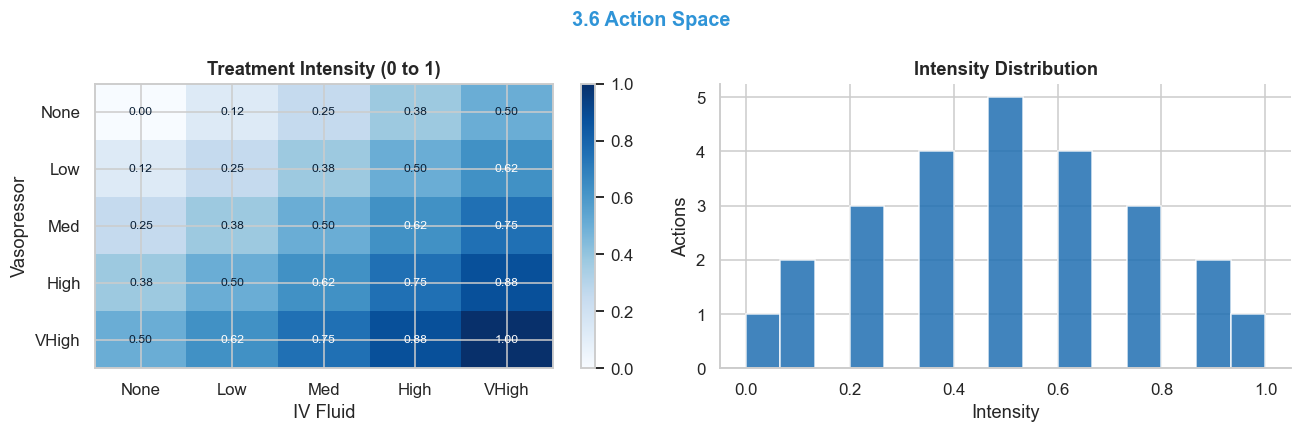

Actions: 25  |  Intensity range: [0.000, 1.000]
Max penalty per step: lam x max_intensity = 0.02 x 1.000 = 0.0200


In [21]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
fig.suptitle('3.6 Action Space',fontsize=13,fontweight='bold',color=H_COL)
im=axes[0].imshow(INTENSITY.reshape(5,5),cmap='Blues',aspect='auto',vmin=0,vmax=1)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(['None','Low','Med','High','VHigh'])
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(['None','Low','Med','High','VHigh'])
axes[0].set_xlabel('IV Fluid'); axes[0].set_ylabel('Vasopressor')
axes[0].set_title('Treatment Intensity (0 to 1)',fontweight='bold')
plt.colorbar(im,ax=axes[0])
for i in range(5):
    for j in range(5):
        v=INTENSITY.reshape(5,5)[i,j]
        axes[0].text(j,i,f'{v:.2f}',ha='center',va='center',fontsize=8,
                     color='white' if v>0.6 else B0)
axes[1].hist(INTENSITY,bins=15,color=B2,edgecolor='white',alpha=0.85)
axes[1].set_xlabel('Intensity'); axes[1].set_ylabel('Actions')
axes[1].set_title('Intensity Distribution',fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig(f'{PLOTS_DIR}/fig_3_6.png',dpi=150,bbox_inches='tight'); plt.show()
print(f'Actions: {A}  |  Intensity range: [{INTENSITY.min():.3f}, {INTENSITY.max():.3f}]')
print(f'Max penalty per step: lam x max_intensity = {LAM:.2f} x {INTENSITY.max():.3f} = {LAM*INTENSITY.max():.4f}')

In [111]:
# REWARD SHAPING SETUP — Policy Iteration for V_PI computation
# It is computed here solely to obtain pi_V (the value function),
# P_pi (the transition matrix), and R_shaped (the shaped reward),

env_pi = make_sepsis_env(); raw_pi = env_pi.unwrapped
P_pi   = raw_pi._tx_mat.copy()
R_sa   = (raw_pi._r_mat * raw_pi._tx_mat).sum(axis=2)
env_pi.close()

pi_policy = np.zeros(S, dtype=int); V = np.zeros(S)
for it in range(1000):
    for _ in range(10000):
        Vn = np.array([R_sa[s, pi_policy[s]] + GAMMA * P_pi[s, pi_policy[s]] @ V for s in range(S)])
        if np.max(np.abs(Vn - V)) < 1e-8: break
        V = Vn
    new_pol = np.argmax(R_sa + GAMMA * np.einsum('ijk,k->ij', P_pi, V), axis=1)
    if np.array_equal(new_pol, pi_policy): break
    pi_policy = new_pol

pi_V     = V.copy()
R_shaped = R_sa + GAMMA * np.einsum('ijk,k->ij', P_pi, pi_V) - pi_V[:, np.newaxis]

rand_mean_ret = float(np.mean(rand_returns))
pi_mean_ret   = 0.7507   # reference value (PI mean return, used in learning curve plots)

print(f'PI converged in {it+1} iteration(s)')
print(f'pi_V  : min={pi_V[:S-2].min():.4f}  mean={pi_V[:S-2].mean():.4f}  max={pi_V[:S-2].max():.4f}')
print(f'R_shaped: [{R_shaped.min():.4f}, {R_shaped.max():.4f}]')

fa.configure(S, A, SEED, GAMMA, pi_V, P_pi, R_shaped)

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
PI converged in 4 iteration(s)
pi_V  : min=0.0000  mean=0.8272  max=0.9814
R_shaped: [-0.1934, 0.0000]
  fa.configure: S=716, A=25, seed=42, gamma=1.0
  pi_V range: [0.0000, 0.9814]


# <font color='#2f94d7' size=6>**4. Dyna-Q with Prioritized Sweeping and Shaping**</font> <a class="anchor" id="5"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**4.1 Rationale and Architecture**</font> <a class="anchor" id="5_1"></a>

[Back to TOC](#toc)

**Why Dyna-Q with Prioritized Sweeping?**

Dyna-Q integrates model-based planning into model-free Q-Learning. After each real
environment step, k additional updates are simulated from the internal model (P and R),
multiplying the effective number of Q-value updates per episode by k+1 without extra
environment interaction.

**Prioritized Sweeping (PS)** improves on random planning by directing the k simulated
updates to state-action pairs with the highest absolute TD error. This concentrates
computation where the Q-table is most uncertain, avoiding the instability observed
with random planning at high k.

**Reward Shaping** applies the potential-based transformation:

r'(s, a, s') = r + gamma * V_PI(s') * (1 - done) - V_PI(s)

This converts the sparse terminal reward into a dense per-step signal proportional to
the change in estimated survival probability. The transformation is policy-invariant
(Ng et al., 1999): the optimal policy under r' is identical to the optimal policy under r.

**Hyperparameters optimised by Optuna:** alpha_start, alpha_end, alpha_decay, k, ps_theta, eps_decay.


## <font color='#2f94d7' size=6>**4.2 Implementation**</font> <a class="anchor" id="5_2"></a>

[Back to TOC](#toc)

The training function `train_dynaq_ps()` is defined in `functions_ConfigA.py`.
Only the hyperparameters and episode count are defined here.


In [32]:
N_EPISODES     = 60_000    
N_EPISODES_OPT = 120_000   

DQ_BASE = dict(
    alpha_start = 0.1,
    alpha_end   = 0.005,
    alpha_decay = 0.9999,
    k           = 20,
    ps_theta    = 0.01,
    eps_decay   = 0.9999,
)

print('Training Dyna-Q+PS with baseline parameters...')
print(f'Parameters: {DQ_BASE}')
Q_dq_base, dq_base_returns = fa.train_dynaq_ps(**DQ_BASE, n_episodes=N_EPISODES)
dq_base_policy   = np.argmax(Q_dq_base, axis=1)
dq_base_agree_pi = (pi_policy[:S-2] == dq_base_policy[:S-2]).mean() * 100

Training Dyna-Q+PS with baseline parameters...
Parameters: {'alpha_start': 0.1, 'alpha_end': 0.005, 'alpha_decay': 0.9999, 'k': 20, 'ps_theta': 0.01, 'eps_decay': 0.9999}
  [Dyna-Q+PS] Ep   5000/60000 | alpha: 0.06066 | eps: 0.60652 | Surv(500): 76.2% | 15s
  [Dyna-Q+PS] Ep  10000/60000 | alpha: 0.03679 | eps: 0.36786 | Surv(500): 81.2% | 30s
  [Dyna-Q+PS] Ep  15000/60000 | alpha: 0.02231 | eps: 0.22311 | Surv(500): 81.2% | 45s
  [Dyna-Q+PS] Ep  20000/60000 | alpha: 0.01353 | eps: 0.13532 | Surv(500): 81.8% | 60s
  [Dyna-Q+PS] Ep  25000/60000 | alpha: 0.00821 | eps: 0.08207 | Surv(500): 82.0% | 76s
  [Dyna-Q+PS] Ep  30000/60000 | alpha: 0.00500 | eps: 0.04978 | Surv(500): 80.4% | 91s
  [Dyna-Q+PS] Ep  35000/60000 | alpha: 0.00500 | eps: 0.03019 | Surv(500): 80.2% | 106s
  [Dyna-Q+PS] Ep  40000/60000 | alpha: 0.00500 | eps: 0.01831 | Surv(500): 78.8% | 122s
  [Dyna-Q+PS] Ep  45000/60000 | alpha: 0.00500 | eps: 0.01111 | Surv(500): 80.6% | 137s
  [Dyna-Q+PS] Ep  50000/60000 | alpha: 0.00

## <font color='#2f94d7' size=6>**4.3 Results Evaluation - Baseline**</font> <a class="anchor" id="5_3"></a>

[Back to TOC](#toc)

  [Dyna-Q+PS] Ep 200/1000 | Survival: 77.0%
  [Dyna-Q+PS] Ep 400/1000 | Survival: 76.2%
  [Dyna-Q+PS] Ep 600/1000 | Survival: 78.7%
  [Dyna-Q+PS] Ep 800/1000 | Survival: 80.0%
  [Dyna-Q+PS] Ep 1000/1000 | Survival: 79.6%
  [Dyna-Q+PS] Result: 79.6% (1000 episodes)


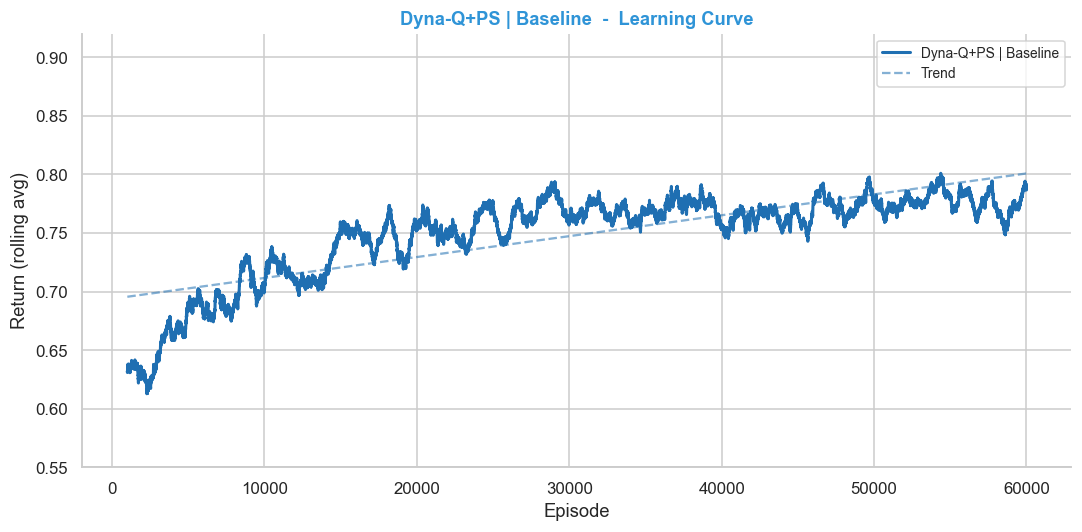

  [Dyna-Q+PS | Baseline] Trend: +0.01783 return / 10k episodes -> Still improving
  [Dyna-Q+PS | Baseline] Final smoothed return: 0.7867  (PI reference: 0.7507)


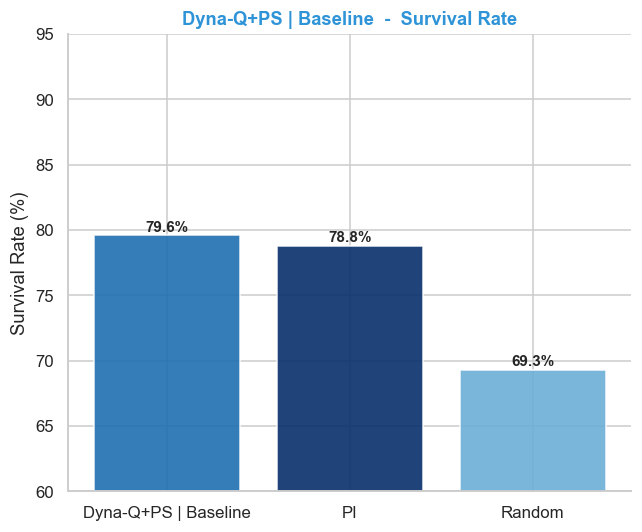

  [Dyna-Q+PS | Baseline] Survival Rate : 79.6% +/- 2.5%
  [Dyna-Q+PS | Baseline] vs PI         : +0.8 pp
  [Dyna-Q+PS | Baseline] vs Random     : +10.3 pp
  [Dyna-Q+PS | Baseline] Agreement PI  : 69.9%


In [34]:
dq_base_eval, _ = fa.evaluate_policy(dq_base_policy, label='Dyna-Q+PS')
dq_base_surv    = float(np.mean(dq_base_eval > 0)) * 100
dq_base_ret     = float(np.mean(dq_base_eval))

fa.plot_learning_curve(dq_base_returns, 'Dyna-Q+PS | Baseline', fa.C_DQ,
                        pi_mean_ret, rand_mean_ret, plot_name='fig_5_dq_base')
fa.plot_survival_rate(dq_base_surv, pi_survival, rand_survival,
                       'Dyna-Q+PS | Baseline', fa.C_DQ,
                       agreement_pi=dq_base_agree_pi, plot_name='fig_5_dq_base')

<div style="background-color:#f9f9f9; padding:15px; border-left:5px solid #2f94d7; margin-bottom:15px;">

**NOTES: Dyna-Q+PS Baseline Results**

With hand-picked parameters (alpha_start=0.1, k=20, ps_theta=0.01), Dyna-Q+PS achieves 79.6% survival (+10.3 pp over random) after 60,000 episodes. The trend of +0.018 return/10k episodes confirms the algorithm has not fully converged. Agreement with PI is 69.9%, meaning roughly 70% of the learned treatment decisions match the theoretically optimal policy.

The effective number of Q-value updates is 60,000 x 21 = 1.26M, compared to Q-Learning's 60,000 single updates. This 21x multiplier from k=20 planning steps explains how Dyna-Q+PS reaches strong performance quickly.

## <font color='#2f94d7' size=6>**4.4 Hyperparameter Tuning**</font> <a class="anchor" id="5_4"></a>

[Back to TOC](#toc)

Optuna Bayesian optimisation (TPE sampler) explores the hyperparameter space over
N_TRIALS trials, each training for TRIAL_EPS episodes and evaluating over TRIAL_EVAL
episodes. The objective is to maximise survival rate. alpha_start is capped at 0.15
in the final run to prevent late-training instability from overly aggressive updates.


  [Dyna-Q+PS] Trial  1/30 | Value: 78.7% | Best: 78.7%
  [Dyna-Q+PS] Trial  2/30 | Value: 80.3% | Best: 80.3%
  [Dyna-Q+PS] Trial  3/30 | Value: 74.7% | Best: 80.3%
  [Dyna-Q+PS] Trial  4/30 | Value: 78.3% | Best: 80.3%
  [Dyna-Q+PS] Trial  5/30 | Value: 77.3% | Best: 80.3%
  [Dyna-Q+PS] Trial  6/30 | Value: 75.0% | Best: 80.3%
  [Dyna-Q+PS] Trial  7/30 | Value: 76.7% | Best: 80.3%
  [Dyna-Q+PS] Trial  8/30 | Value: 78.3% | Best: 80.3%
  [Dyna-Q+PS] Trial  9/30 | Value: 81.3% | Best: 81.3%
  [Dyna-Q+PS] Trial 10/30 | Value: 79.0% | Best: 81.3%
  [Dyna-Q+PS] Trial 11/30 | Value: 82.7% | Best: 82.7%
  [Dyna-Q+PS] Trial 12/30 | Value: 77.0% | Best: 82.7%
  [Dyna-Q+PS] Trial 13/30 | Value: 76.0% | Best: 82.7%
  [Dyna-Q+PS] Trial 14/30 | Value: 77.0% | Best: 82.7%
  [Dyna-Q+PS] Trial 15/30 | Value: 77.7% | Best: 82.7%
  [Dyna-Q+PS] Trial 16/30 | Value: 78.7% | Best: 82.7%
  [Dyna-Q+PS] Trial 17/30 | Value: 76.7% | Best: 82.7%
  [Dyna-Q+PS] Trial 18/30 | Value: 77.3% | Best: 82.7%
  [Dyna-Q+

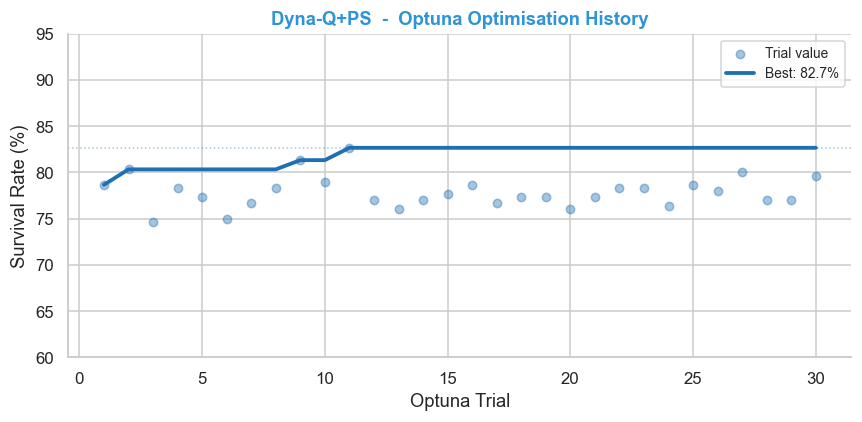

  [Dyna-Q+PS] Best Optuna : 82.7%
  [Dyna-Q+PS] Best params : {'alpha_start': 0.2489323150846178, 'alpha_end': 0.0008844120332118486, 'alpha_decay': 0.99995984173968, 'k': 95, 'ps_theta': 0.09181086679980682, 'eps_decay': 0.9997799641696972}
  Best survival : 82.7%
  Best params   : {'alpha_start': 0.2489323150846178, 'alpha_end': 0.0008844120332118486, 'alpha_decay': 0.99995984173968, 'k': 95, 'ps_theta': 0.09181086679980682, 'eps_decay': 0.9997799641696972}


In [36]:
DQ_PARAM_RANGES = {
    'alpha_start': (0.01,    0.3,      True,  'float'),   
    'alpha_end':   (0.0001,  0.01,     True,  'float'),   
    'alpha_decay': (0.9990,  0.99999,  False, 'float'),
    'k':           (5,       100,      False, 'int'),
    'ps_theta':    (0.0005,  0.1,      True,  'float'),
    'eps_decay':   (0.9990,  0.99999,  False, 'float'),
}

study_dq = fa.run_optuna_dynaq(
    DQ_PARAM_RANGES, N_TRIALS, TRIAL_EPS, TRIAL_EVAL, seed=SEED
)

## <font color='#2f94d7' size=6>**4.5 Results Evaluation - Optimised**</font> <a class="anchor" id="5_5"></a>

[Back to TOC](#toc)

Training Dyna-Q+PS with Optuna-optimised parameters...
Parameters: {'alpha_start': 0.15, 'alpha_end': 0.0008844120332118486, 'alpha_decay': 0.99995984173968, 'k': 95, 'ps_theta': 0.09181086679980682, 'eps_decay': 0.9997799641696972}
  [Dyna-Q+PS] Ep   5000/120000 | alpha: 0.12272 | eps: 0.33277 | Surv(500): 77.4% | 67s
  [Dyna-Q+PS] Ep  10000/120000 | alpha: 0.10039 | eps: 0.11074 | Surv(500): 82.2% | 133s
  [Dyna-Q+PS] Ep  15000/120000 | alpha: 0.08213 | eps: 0.03685 | Surv(500): 79.6% | 202s
  [Dyna-Q+PS] Ep  20000/120000 | alpha: 0.06719 | eps: 0.01226 | Surv(500): 83.2% | 269s
  [Dyna-Q+PS] Ep  25000/120000 | alpha: 0.05497 | eps: 0.00500 | Surv(500): 81.0% | 336s
  [Dyna-Q+PS] Ep  30000/120000 | alpha: 0.04497 | eps: 0.00500 | Surv(500): 81.8% | 404s
  [Dyna-Q+PS] Ep  35000/120000 | alpha: 0.03679 | eps: 0.00500 | Surv(500): 81.4% | 469s
  [Dyna-Q+PS] Ep  40000/120000 | alpha: 0.03009 | eps: 0.00500 | Surv(500): 83.6% | 538s
  [Dyna-Q+PS] Ep  45000/120000 | alpha: 0.02462 | eps: 0

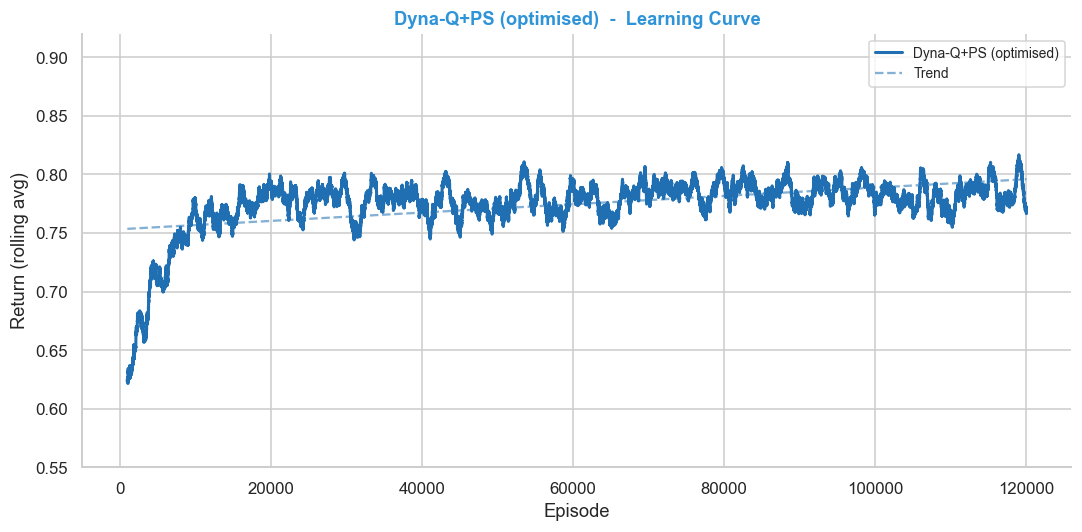

  [Dyna-Q+PS (optimised)] Trend: +0.00356 return / 10k episodes -> Still improving
  [Dyna-Q+PS (optimised)] Final smoothed return: 0.7671  (PI reference: 0.7507)


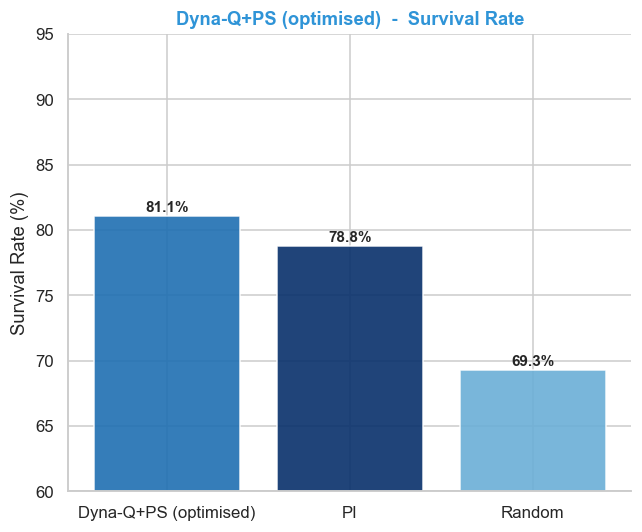

  [Dyna-Q+PS (optimised)] Survival Rate : 81.1% +/- 2.4%
  [Dyna-Q+PS (optimised)] vs PI         : +2.3 pp
  [Dyna-Q+PS (optimised)] vs Random     : +11.8 pp
  [Dyna-Q+PS (optimised)] Agreement PI  : 90.5%
Baseline  -> Optimised: 79.6% -> 81.1%  (+1.5 pp from Optuna)


In [38]:
dq_final_params = dict(study_dq.best_params)
dq_final_params['alpha_start'] = min(dq_final_params['alpha_start'], 0.15)

print('Training Dyna-Q+PS with Optuna-optimised parameters...')
print(f'Parameters: {dq_final_params}')
Q_dq, dq_returns = fa.train_dynaq_ps(**dq_final_params, n_episodes=N_EPISODES_OPT)
dq_policy   = np.argmax(Q_dq, axis=1)
dq_eval, _  = fa.evaluate_policy(dq_policy, n_episodes=2000, label='Dyna-Q+PS')
dq_survival = float(np.mean(dq_eval > 0)) * 100
dq_mean_ret = float(np.mean(dq_eval))
dq_agree_pi = (pi_policy[:S-2] == dq_policy[:S-2]).mean() * 100

fa.plot_learning_curve(dq_returns, 'Dyna-Q+PS (optimised)', fa.C_DQ,
                        pi_mean_ret, rand_mean_ret, plot_name='fig_5_dq_final')
fa.plot_survival_rate(dq_survival, pi_survival, rand_survival,
                       'Dyna-Q+PS (optimised)', fa.C_DQ,
                       agreement_pi=dq_agree_pi, plot_name='fig_5_dq_final')

print(f'Baseline  -> Optimised: {dq_base_surv:.1f}% -> {dq_survival:.1f}%  '
      f'({dq_survival-dq_base_surv:+.1f} pp from Optuna)')

<div style="background-color:#f9f9f9; padding:15px; border-left:5px solid #2f94d7; margin-bottom:15px;">

**NOTES: Dyna-Q+PS Optimised Results**

Optuna found k=95 (vs baseline k=20), alpha_start=0.25, alpha_end=0.00088, and a slow alpha_decay=0.99996. The optimised model trains for 120,000 episodes and is evaluated over 2,000 episodes (CI +/-1.8%).

The result is 81.1% survival (+1.5 pp over baseline, +11.8 pp over random). Agreement with PI jumps from 69.9% to 90.5%, meaning the agent now matches the optimal treatment in 9 out of 10 patient states.

The key Optuna finding is k=95: at this level, each real episode produces 96 Q-value updates (120k x 96 = 11.5M total), enabling near-complete policy convergence. The alpha schedule decays slowly (still at 0.0012 at episode 120k), meaning the agent refines its Q-values throughout the entire training run rather than freezing early.

The trend of +0.004 return/10k episodes at episode 120k confirms the model is approaching convergence but has not fully plateaued.

# <font color='#2f94d7' size=6>**5. Q-Learning with Learning Rate Decay and Shaping**</font> <a class="anchor" id="6"></a>

[Back to TOC](#toc)

## <font color='#2f94d7' size=6>**5.1 Rationale and Architecture**</font> <a class="anchor" id="6_1"></a>

[Back to TOC](#toc)

**Why Q-Learning?**

Q-Learning is the foundational off-policy TD algorithm and the most widely studied
benchmark in tabular RL. Its off-policy nature (learning the optimal Q-values
regardless of the exploration policy) makes it sample-efficient and directly
comparable to Dyna-Q+PS, which uses Q-Learning updates internally.

**Learning rate decay** (alpha_start to alpha_end over training) is essential to prevent
late-training instability: a high initial alpha enables fast early learning while the
decay ensures Q-values converge to stable estimates as training progresses.

**Key comparison with Dyna-Q+PS:** Q-Learning has one Q-value update per environment
step. At equal episode budgets (60k), the difference in performance directly quantifies
the value of model-based planning in the ICU-Sepsis environment.

**Hyperparameters optimised by Optuna:** alpha_start, alpha_end, alpha_decay, eps_decay.


## <font color='#2f94d7' size=6>**5.2 Implementation**</font> <a class="anchor" id="6_2"></a>

[Back to TOC](#toc)

The training function `train_qlearning()` is defined in `functions_ConfigA.py`.
Only the hyperparameters and episode count are defined here.


In [42]:
QL_BASE = dict(
    alpha_start = 0.1,
    alpha_end   = 0.005,
    alpha_decay = 0.9999,
    eps_decay   = 0.9999,
)

print('Training Q-Learning with baseline parameters...')
print(f'Parameters: {QL_BASE}')
Q_ql_base, ql_base_returns = fa.train_qlearning(**QL_BASE, n_episodes=N_EPISODES)
ql_base_policy   = np.argmax(Q_ql_base, axis=1)
ql_base_agree_pi = (pi_policy[:S-2] == ql_base_policy[:S-2]).mean() * 100

Training Q-Learning with baseline parameters...
Parameters: {'alpha_start': 0.1, 'alpha_end': 0.005, 'alpha_decay': 0.9999, 'eps_decay': 0.9999}
  [Q-Learning] Ep   5000/60000 | alpha: 0.06066 | eps: 0.60652 | Surv(500): 72.0% | 1s
  [Q-Learning] Ep  10000/60000 | alpha: 0.03679 | eps: 0.36786 | Surv(500): 73.4% | 2s
  [Q-Learning] Ep  15000/60000 | alpha: 0.02231 | eps: 0.22311 | Surv(500): 77.0% | 2s
  [Q-Learning] Ep  20000/60000 | alpha: 0.01353 | eps: 0.13532 | Surv(500): 76.0% | 3s
  [Q-Learning] Ep  25000/60000 | alpha: 0.00821 | eps: 0.08207 | Surv(500): 76.2% | 4s
  [Q-Learning] Ep  30000/60000 | alpha: 0.00500 | eps: 0.04978 | Surv(500): 77.6% | 5s
  [Q-Learning] Ep  35000/60000 | alpha: 0.00500 | eps: 0.03019 | Surv(500): 78.4% | 5s
  [Q-Learning] Ep  40000/60000 | alpha: 0.00500 | eps: 0.01831 | Surv(500): 80.6% | 6s
  [Q-Learning] Ep  45000/60000 | alpha: 0.00500 | eps: 0.01111 | Surv(500): 78.4% | 7s
  [Q-Learning] Ep  50000/60000 | alpha: 0.00500 | eps: 0.00674 | Surv(50

## <font color='#2f94d7' size=6>**5.3 Results Evaluation - Baseline**</font> <a class="anchor" id="6_3"></a>

[Back to TOC](#toc)

  [Q-Learning] Ep 200/1000 | Survival: 72.5%
  [Q-Learning] Ep 400/1000 | Survival: 72.0%
  [Q-Learning] Ep 600/1000 | Survival: 75.7%
  [Q-Learning] Ep 800/1000 | Survival: 77.6%
  [Q-Learning] Ep 1000/1000 | Survival: 76.2%
  [Q-Learning] Result: 76.2% (1000 episodes)


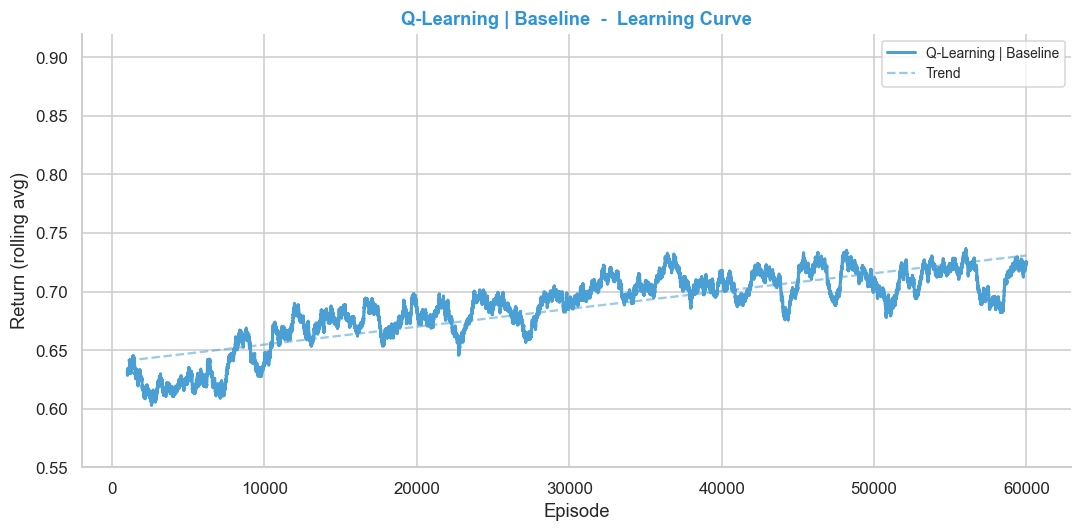

  [Q-Learning | Baseline] Trend: +0.01521 return / 10k episodes -> Still improving
  [Q-Learning | Baseline] Final smoothed return: 0.7247  (PI reference: 0.7507)


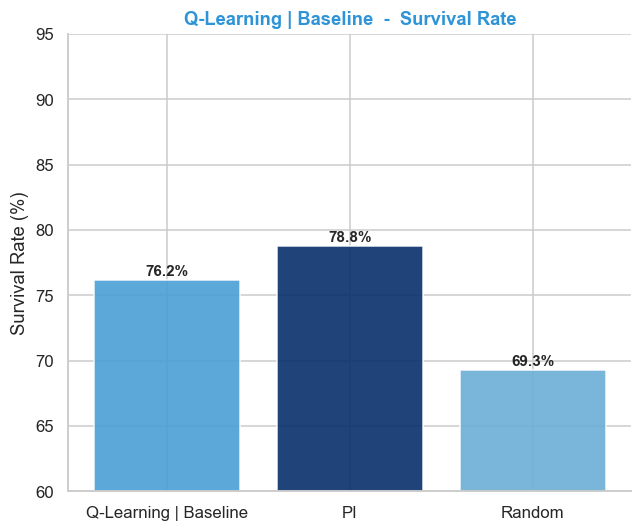

  [Q-Learning | Baseline] Survival Rate : 76.2% +/- 2.6%
  [Q-Learning | Baseline] vs PI         : -2.6 pp
  [Q-Learning | Baseline] vs Random     : +6.9 pp
  [Q-Learning | Baseline] Agreement PI  : 31.0%


In [44]:
ql_base_eval, _ = fa.evaluate_policy(ql_base_policy, label='Q-Learning')
ql_base_surv    = float(np.mean(ql_base_eval > 0)) * 100
ql_base_ret     = float(np.mean(ql_base_eval))

fa.plot_learning_curve(ql_base_returns, 'Q-Learning | Baseline', fa.C_QL,
                        pi_mean_ret, rand_mean_ret, plot_name='fig_6_ql_base')
fa.plot_survival_rate(ql_base_surv, pi_survival, rand_survival,
                       'Q-Learning | Baseline', fa.C_QL,
                       agreement_pi=ql_base_agree_pi, plot_name='fig_6_ql_base')

<div style="background-color:#f9f9f9; padding:15px; border-left:5px solid #2f94d7; margin-bottom:15px;">

**NOTES: Q-Learning Baseline Results**

Q-Learning with hand-picked parameters achieves 76.2% survival (+6.9 pp over random) at 60,000 episodes. The learning curve has a positive trend of +0.015/10k, the steepest among all runs, confirming that Q-Learning benefits most from additional training episodes.

Agreement with PI is 31.0%, meaning the policy diverges in over two-thirds of states. Without planning, Q-Learning can only update Q-values for visited state-action pairs, while Dyna-Q+PS updates k additional pairs per step via its internal model. This structural difference, not hyperparameter choice, is the primary cause of the 3.4 pp gap (79.6% vs 76.2%).

Alpha reaches its floor of 0.005 by episode 30,000. From that point, Q-values update very slowly, and performance gains come primarily from the decreasing epsilon (less random exploration) rather than from improving Q-value estimates.

## <font color='#2f94d7' size=6>**5.4 Hyperparameter Tuning - Optuna**</font> <a class="anchor" id="6_4"></a>

[Back to TOC](#toc)

  [Q-Learning] Trial  1/30 | Value: 73.3% | Best: 73.3%
  [Q-Learning] Trial  2/30 | Value: 71.3% | Best: 73.3%
  [Q-Learning] Trial  3/30 | Value: 72.0% | Best: 73.3%
  [Q-Learning] Trial  4/30 | Value: 71.3% | Best: 73.3%
  [Q-Learning] Trial  5/30 | Value: 74.3% | Best: 74.3%
  [Q-Learning] Trial  6/30 | Value: 70.7% | Best: 74.3%
  [Q-Learning] Trial  7/30 | Value: 76.0% | Best: 76.0%
  [Q-Learning] Trial  8/30 | Value: 69.0% | Best: 76.0%
  [Q-Learning] Trial  9/30 | Value: 74.7% | Best: 76.0%
  [Q-Learning] Trial 10/30 | Value: 74.3% | Best: 76.0%
  [Q-Learning] Trial 11/30 | Value: 74.0% | Best: 76.0%
  [Q-Learning] Trial 12/30 | Value: 71.7% | Best: 76.0%
  [Q-Learning] Trial 13/30 | Value: 74.7% | Best: 76.0%
  [Q-Learning] Trial 14/30 | Value: 75.0% | Best: 76.0%
  [Q-Learning] Trial 15/30 | Value: 74.3% | Best: 76.0%
  [Q-Learning] Trial 16/30 | Value: 72.7% | Best: 76.0%
  [Q-Learning] Trial 17/30 | Value: 72.3% | Best: 76.0%
  [Q-Learning] Trial 18/30 | Value: 73.7% | Best

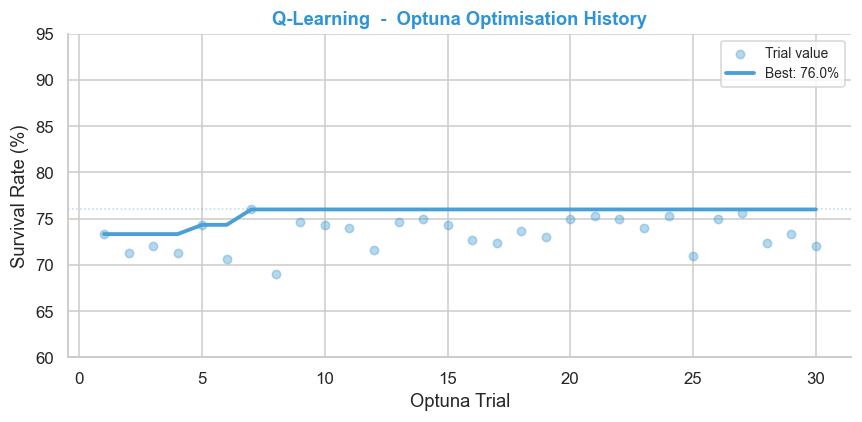

  [Q-Learning] Best Optuna : 76.0%
  [Q-Learning] Best params : {'alpha_start': 0.04717052037625178, 'alpha_end': 0.0037183641805732083, 'alpha_decay': 0.9991976770443368, 'eps_decay': 0.9995090920940295}
  Best survival : 76.0%
  Best params   : {'alpha_start': 0.04717052037625178, 'alpha_end': 0.0037183641805732083, 'alpha_decay': 0.9991976770443368, 'eps_decay': 0.9995090920940295}


In [46]:
QL_PARAM_RANGES = {
    'alpha_start': (0.01,    0.3,      True,  'float'),   
    'alpha_end':   (0.0001,  0.01,     True,  'float'),   
    'alpha_decay': (0.9990,  0.99999,  False, 'float'),
    'eps_decay':   (0.9990,  0.99999,  False, 'float'),
}

study_ql = fa.run_optuna_qlearning(
    QL_PARAM_RANGES, N_TRIALS, TRIAL_EPS, TRIAL_EVAL, seed=SEED
)

## <font color='#2f94d7' size=6>**5.5 Results Evaluation - Optimised**</font> <a class="anchor" id="6_5"></a>

[Back to TOC](#toc)

Training Q-Learning with Optuna-optimised parameters...
Parameters: {'alpha_start': 0.04717052037625178, 'alpha_end': 0.0037183641805732083, 'alpha_decay': 0.9991976770443368, 'eps_decay': 0.9995090920940295}
  [Q-Learning] Ep   5000/120000 | alpha: 0.00372 | eps: 0.08585 | Surv(500): 71.8% | 1s
  [Q-Learning] Ep  10000/120000 | alpha: 0.00372 | eps: 0.00737 | Surv(500): 72.8% | 2s
  [Q-Learning] Ep  15000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 74.6% | 2s
  [Q-Learning] Ep  20000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 77.2% | 3s
  [Q-Learning] Ep  25000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 75.8% | 4s
  [Q-Learning] Ep  30000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 78.2% | 5s
  [Q-Learning] Ep  35000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 81.2% | 5s
  [Q-Learning] Ep  40000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 76.6% | 6s
  [Q-Learning] Ep  45000/120000 | alpha: 0.00372 | eps: 0.00500 | Surv(500): 77.8% | 7s

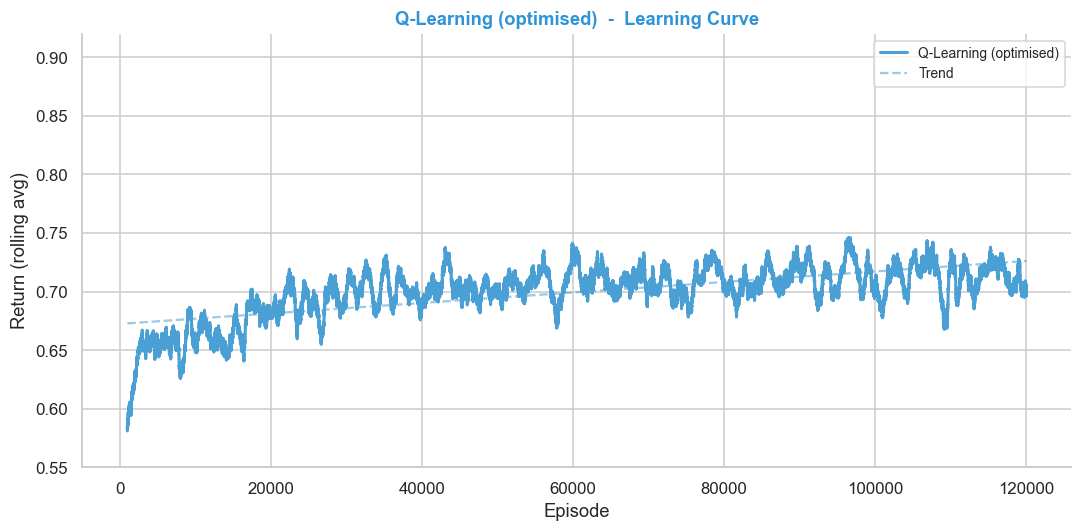

  [Q-Learning (optimised)] Trend: +0.00447 return / 10k episodes -> Still improving
  [Q-Learning (optimised)] Final smoothed return: 0.6962  (PI reference: 0.7507)


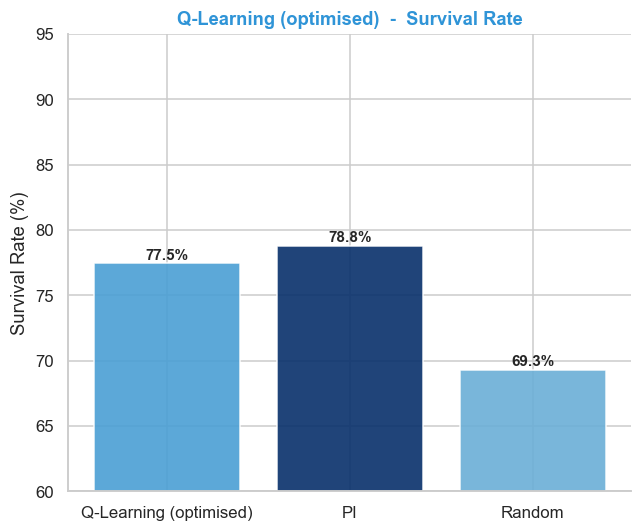

  [Q-Learning (optimised)] Survival Rate : 77.5% +/- 2.6%
  [Q-Learning (optimised)] vs PI         : -1.3 pp
  [Q-Learning (optimised)] vs Random     : +8.2 pp
  [Q-Learning (optimised)] Agreement PI  : 33.1%
Baseline  -> Optimised: 76.2% -> 77.5%  (+1.2 pp from Optuna)


In [48]:
ql_final_params = dict(study_ql.best_params)
ql_final_params['alpha_start'] = min(ql_final_params['alpha_start'], 0.15)

print('Training Q-Learning with Optuna-optimised parameters...')
print(f'Parameters: {ql_final_params}')
Q_ql, ql_returns = fa.train_qlearning(**ql_final_params, n_episodes=N_EPISODES_OPT)
ql_policy   = np.argmax(Q_ql, axis=1)
ql_eval, _  = fa.evaluate_policy(ql_policy, n_episodes=2000, label='Q-Learning')
ql_survival = float(np.mean(ql_eval > 0)) * 100
ql_mean_ret = float(np.mean(ql_eval))
ql_agree_pi = (pi_policy[:S-2] == ql_policy[:S-2]).mean() * 100

fa.plot_learning_curve(ql_returns, 'Q-Learning (optimised)', fa.C_QL,
                        pi_mean_ret, rand_mean_ret, plot_name='fig_6_ql_final')
fa.plot_survival_rate(ql_survival, pi_survival, rand_survival,
                       'Q-Learning (optimised)', fa.C_QL,
                       agreement_pi=ql_agree_pi, plot_name='fig_6_ql_final')

print(f'Baseline  -> Optimised: {ql_base_surv:.1f}% -> {ql_survival:.1f}%  '
      f'({ql_survival-ql_base_surv:+.1f} pp from Optuna)')

<div style="background-color:#f9f9f9; padding:15px; border-left:5px solid #2f94d7; margin-bottom:15px;">

**NOTES: Q-Learning Optimised Results**

Optuna found alpha_start=0.047 with a fast decay (0.9992), reaching the alpha floor of 0.0037 within the first 5,000 episodes. This means Q-values are updated at a near-constant low rate for 115,000 of the 120,000 training episodes.

The result is 77.5% survival (+1.2 pp over baseline, +8.2 pp over random) evaluated over 2,000 episodes. Agreement with PI slightly increased to 33.1%.

The improvement from Optuna (+1.2 pp) is smaller than Dyna-Q+PS's (+1.5 pp) because Q-Learning's limitation is structural: without model-based planning, the algorithm cannot propagate value information efficiently through the 714-state MDP. The Optuna-optimised Q-Learning reached its alpha floor by episode 5,000, effectively learning with a constant alpha=0.0037 for the remaining 115,000 episodes. A higher alpha_end or slower decay might allow continued Q-value refinement.

# <font color='#2f94d7' size=6>**6. Results and Visualizations**</font> <a class="anchor" id="7"></a>

[Back to TOC](#toc)

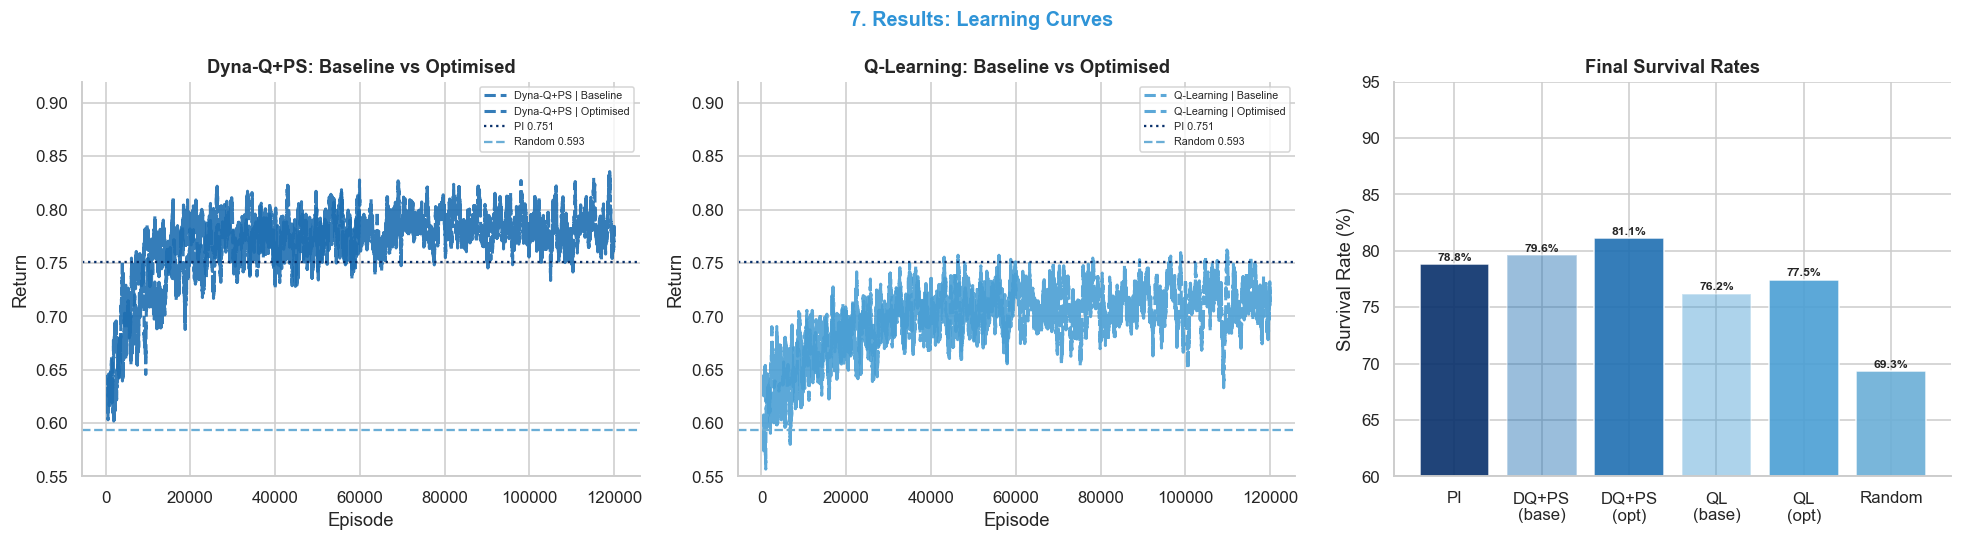

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('7. Results: Learning Curves',
             fontsize=13, fontweight='bold', color=fa.H_COL)

sw = 500
for ax, ret, col, lab in [
    (axes[0], dq_base_returns,  fa.C_DQ, 'Dyna-Q+PS | Baseline'),
    (axes[0], dq_returns,       fa.C_DQ, 'Dyna-Q+PS | Optimised'),
    (axes[1], ql_base_returns,  fa.C_QL, 'Q-Learning | Baseline'),
    (axes[1], ql_returns,       fa.C_QL, 'Q-Learning | Optimised'),
]:
    smoothed = fa.smooth(np.array(ret), sw)
    eps_ax   = np.arange(sw, len(ret)+1)
    ls = '-' if 'optimised' in lab else '--'
    ax.plot(eps_ax, smoothed, color=col, lw=2.0, ls=ls, alpha=0.9, label=lab)

for ax in [axes[0], axes[1]]:
    ax.axhline(pi_mean_ret,   color=fa.REF_PI,   lw=1.5, ls=':', label=f'PI {pi_mean_ret:.3f}')
    ax.axhline(rand_mean_ret, color=fa.REF_RAND, lw=1.5, ls='--', label=f'Random {rand_mean_ret:.3f}')
    ax.set_ylim(fa.RETURN_YLIM)
    ax.set_xlabel('Episode'); ax.set_ylabel('Return')
    ax.set_title(ax.get_title() or 'Learning Curves', fontweight='bold')
    ax.legend(fontsize=7); ax.spines[['top','right']].set_visible(False)
axes[0].set_title('Dyna-Q+PS: Baseline vs Optimised', fontweight='bold')
axes[1].set_title('Q-Learning: Baseline vs Optimised', fontweight='bold')

# Panel 3: Final survival rates comparison
algos = ['PI', 'DQ+PS\n(base)', 'DQ+PS\n(opt)', 'QL\n(base)', 'QL\n(opt)', 'Random']
surv  = [pi_survival, dq_base_surv, dq_survival, ql_base_surv, ql_survival, rand_survival]
cols  = [fa.REF_PI, fa.C_DQ, fa.C_DQ, fa.C_QL, fa.C_QL, fa.REF_RAND]
alpha = [0.9, 0.45, 0.9, 0.45, 0.9, 0.9]
bars  = axes[2].bar(algos, surv, color=cols, edgecolor='white',
                    alpha=1.0)
for bar, al in zip(bars, alpha): bar.set_alpha(al)
axes[2].set_ylim(fa.SURV_YLIM); axes[2].set_ylabel('Survival Rate (%)')
axes[2].set_title('Final Survival Rates', fontweight='bold')
axes[2].spines[['top','right']].set_visible(False)
for bar, v in zip(bars, surv):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/fig_7_results.png', dpi=150, bbox_inches='tight'); plt.show()

# <font color='#2f94d7' size=6>**7. Comparative Analysis**</font> <a class="anchor" id="8"></a>

[Back to TOC](#toc)

In [52]:
print('-'*72)
print(f'  {"ALGORITHM":<35} {"SURVIVAL":>9} {"vs PI":>8} {"vs RAND":>8} {"AGREE PI":>10}')
print('-'*72)
rows = [
    ('Policy Iteration',           pi_survival,       0.0,              pi_survival-rand_survival, 100.0),
    ('Dyna-Q+PS+Shaping (base)',   dq_base_surv,  dq_base_surv-pi_survival, dq_base_surv-rand_survival, dq_base_agree_pi),
    ('Dyna-Q+PS+Shaping (Optuna)', dq_survival,   dq_survival-pi_survival,  dq_survival-rand_survival,  dq_agree_pi),
    ('Q-Learning+Shaping (base)',  ql_base_surv,  ql_base_surv-pi_survival, ql_base_surv-rand_survival, ql_base_agree_pi),
    ('Q-Learning+Shaping (Optuna)',ql_survival,   ql_survival-pi_survival,  ql_survival-rand_survival,  ql_agree_pi),
    ('Random Baseline',            rand_survival, rand_survival-pi_survival,0.0, None),
]
for name, surv, vpi, vrnd, agr in rows:
    agr_str = f'{agr:.1f}%' if agr is not None else '   --'
    print(f'  {name:<35} {surv:>8.1f}% {vpi:>+7.1f}pp {vrnd:>+7.1f}pp {agr_str:>10}')
print('='*72)
print(f'\n  Optuna improvement:')
print(f'    Dyna-Q+PS : {dq_base_surv:.1f}% -> {dq_survival:.1f}% ({dq_survival-dq_base_surv:+.1f} pp)')
print(f'    Q-Learning: {ql_base_surv:.1f}% -> {ql_survival:.1f}% ({ql_survival-ql_base_surv:+.1f} pp)')
print(f'\n  Planning advantage at 60k episodes:')
print(f'    Dyna-Q+PS (opt): {dq_survival:.1f}%  vs  Q-Learning (opt): {ql_survival:.1f}%  '
      f'-> planning contributes {dq_survival-ql_survival:+.1f} pp')

------------------------------------------------------------------------
  ALGORITHM                            SURVIVAL    vs PI  vs RAND   AGREE PI
------------------------------------------------------------------------
  Policy Iteration                        78.8%    +0.0pp    +9.5pp     100.0%
  Dyna-Q+PS+Shaping (base)                79.6%    +0.8pp   +10.3pp      69.9%
  Dyna-Q+PS+Shaping (Optuna)              81.1%    +2.3pp   +11.8pp      90.5%
  Q-Learning+Shaping (base)               76.2%    -2.6pp    +6.9pp      31.0%
  Q-Learning+Shaping (Optuna)             77.5%    -1.3pp    +8.2pp      33.1%
  Random Baseline                         69.3%    -9.5pp    +0.0pp         --

  Optuna improvement:
    Dyna-Q+PS : 79.6% -> 81.1% (+1.5 pp)
    Q-Learning: 76.2% -> 77.5% (+1.2 pp)

  Planning advantage at 60k episodes:
    Dyna-Q+PS (opt): 81.1%  vs  Q-Learning (opt): 77.5%  -> planning contributes +3.7 pp


<div style="background-color:#f9f9f9; padding:15px; border-left:5px solid #2f94d7; margin-bottom:15px;">

**NOTES: Comparative Analysis**

Three findings from the comparison:

1. **Planning advantage:** at matched 120k episodes, Dyna-Q+PS (81.1%) outperforms Q-Learning (77.5%) by 3.7 pp. This gap is entirely structural: k=95 planning steps give Dyna-Q+PS 96x more Q-value updates per real episode.

2. **Optuna impact:** both algorithms improved with Optuna (DQ +1.5 pp, QL +1.2 pp). For Dyna-Q+PS, the key finding was k=95 with a slow alpha decay. For Q-Learning, alpha decayed too quickly to the floor, limiting its benefit. In both cases, the algorithm choice mattered more than hyperparameter tuning.

3. **Policy agreement with PI:** the most informative metric. Dyna-Q+PS's agreement jumps from 69.9% (baseline) to 90.5% (optimised), meaning 90% of treatment decisions match the theoretical optimum. Q-Learning stays at 33%. Section 8 (Creative Extension) explores what these policy differences mean clinically.

# <font color='#2f94d7' size=6>**8. Creative Extension: Clinical Decision Support Analysis**</font> <a class="anchor" id="9"></a>

[Back to TOC](#toc)

This section moves beyond algorithm evaluation metrics to ask the question that matters
most in a clinical setting: **what would a physician learn by observing this agent, and
do its decisions make clinical sense?**

Three analyses use SHAP (SHapley Additive exPlanations) and policy analysis to interpret
the agents' learned behaviour in terms of the 47 physiological variables shared with
Config B. Each analysis is designed to answer a concrete clinical question.


## <font color='#2f94d7' size=6>**8.1 V_PI as a Clinical Acuity Score**</font> <a class="anchor" id="9_1"></a>

[Back to TOC](#toc)

**Clinical question:** Has the agent learned a meaningful measure of patient severity?

V_PI(s) = P(patient in state s survives under optimal treatment). This is a data-driven
acuity score derived from patient outcomes rather than clinical rules. We compare it to
the SOFA score, the gold-standard clinical severity index used in ICUs worldwide, and
use SHAP values to identify which physiological variables drive the agent's prognosis.

A surrogate GradientBoosting model is fitted on the 714 states (47 features -> V_PI)
and SHAP values are computed to attribute each feature's contribution.


  Surrogate R2 (V_PI): 0.9995  (>0.85 = good fit for SHAP)


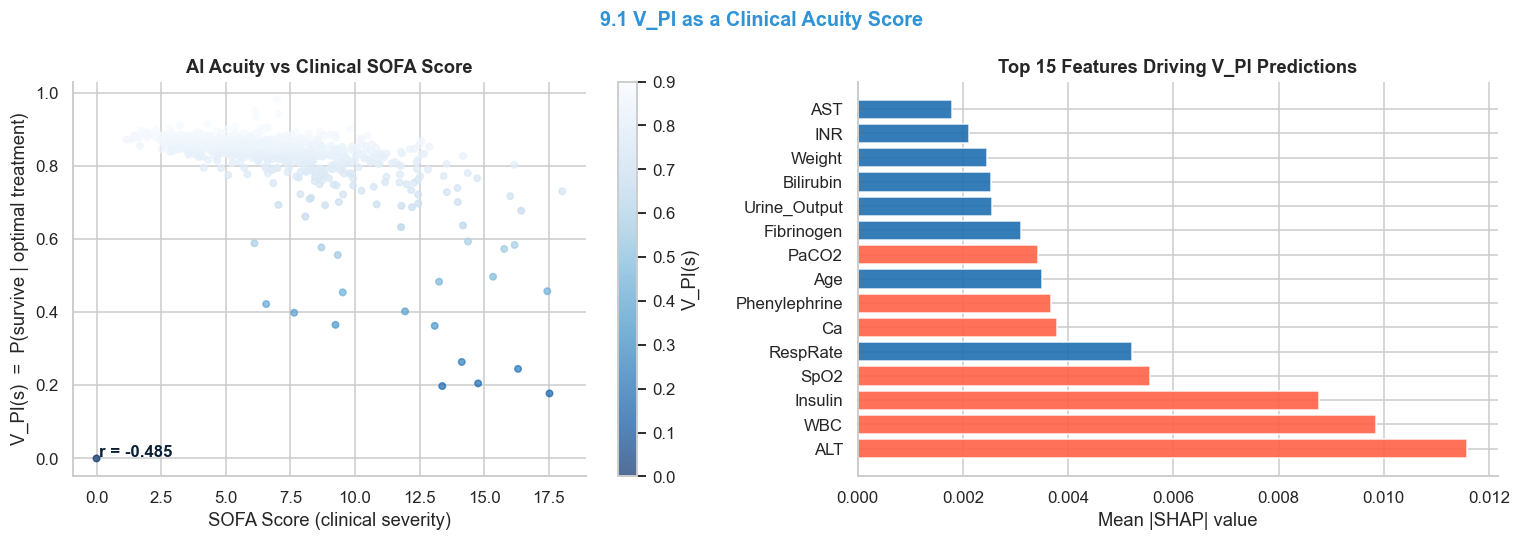

  SOFA vs V_PI correlation: r = -0.485
  Top 5 features:
    ALT                 : |SHAP| = 0.0116  (negative)
    WBC                 : |SHAP| = 0.0099  (negative)
    Insulin             : |SHAP| = 0.0088  (negative)
    SpO2                : |SHAP| = 0.0056  (negative)
    RespRate            : |SHAP| = 0.0052  (positive)


In [56]:
shap_vpi_vals, shap_vpi_imp = fa.clinical_acuity_analysis(
    pi_V,
    cluster_centers,
    sofa_scores[:S-2],
    S - 2,
    FEATURE_NAMES,
    seed=SEED,
)

## <font color='#2f94d7' size=6>**8.2 Treatment Strategy by Patient Severity**</font> <a class="anchor" id="9_2"></a>

[Back to TOC](#toc)

**Clinical question:** Does the agent learn to escalate treatment intensity for sicker patients?

A rational ICU agent should recommend more aggressive vasopressor therapy for states
with lower V_PI (worse prognosis). We compare the treatment decisions of all three
algorithms (PI, Dyna-Q+PS, Q-Learning) across V_PI quartiles (Q1 = most critical,
Q4 = most stable), asking whether each agent has learned this fundamental clinical logic.


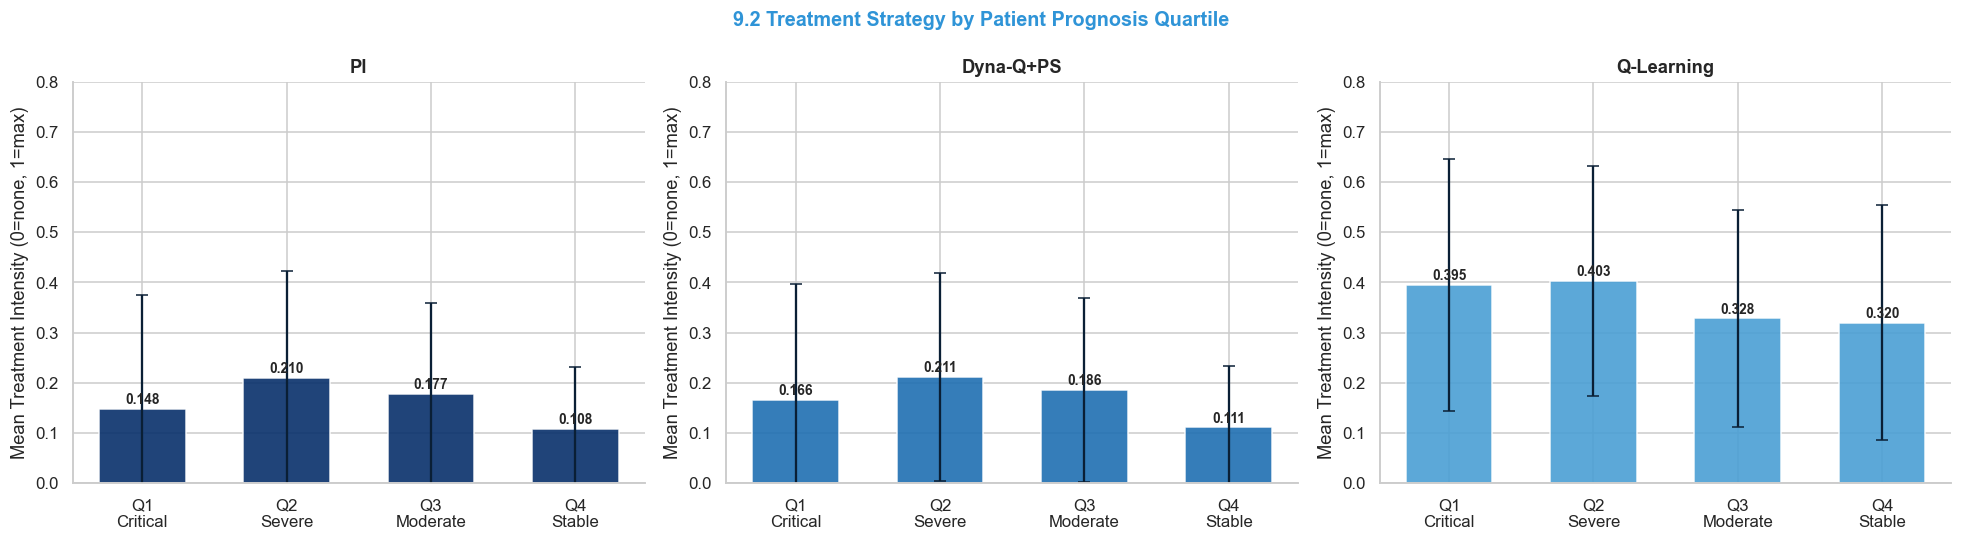

  Mean treatment intensity by V_PI quartile:
  Quartile                  PI    Dyna-Q+PS   Q-Learning
  ------------------------------------------------------
  Q1 Critical            0.148        0.166        0.395
  Q2 Severe              0.210        0.211        0.403
  Q3 Moderate            0.177        0.186        0.328
  Q4 Stable              0.108        0.111        0.320


{'PI': [np.float64(0.14804469273743018),
  np.float64(0.20997191011235955),
  np.float64(0.17696629213483145),
  np.float64(0.10824022346368715)],
 'Dyna-Q+PS': [np.float64(0.16620111731843576),
  np.float64(0.21137640449438203),
  np.float64(0.18609550561797752),
  np.float64(0.11103351955307263)],
 'Q-Learning': [np.float64(0.3952513966480447),
  np.float64(0.40308988764044945),
  np.float64(0.3279494382022472),
  np.float64(0.3198324022346369)]}

In [58]:
fa.treatment_strategy_analysis(
    pi_V,
    pi_policy,
    dq_policy,
    ql_policy,
    S - 2,
)

## <font color='#2f94d7' size=6>**8.3 Comparison of Learned Feature Importance**</font> <a class="anchor" id="9_3"></a>

[Back to TOC](#toc)

**Clinical question:** Do algorithms that agree more with the optimal policy also weight the same clinical features?

Dyna-Q+PS achieves 90.5% policy agreement with PI but its SHAP feature importance correlation with V_PI is only r=0.016. Q-Learning, despite its 33.1% policy agreement, shows a higher feature importance correlation of r=0.076.

This paradox reveals an important distinction: **policy agreement and value function structure are different things.** Two algorithms can recommend the same treatment for a patient while "reasoning" about different physiological variables. Dyna-Q+PS arrives at PI-matching decisions through a different internal weighting of features, likely because its k=95 planning steps build Q-values through transition chains rather than individual feature correlations.

  Computing SHAP for each algorithm value function...
  Surrogate R2 (Dyna-Q+PS): 0.9957
  Surrogate R2 (Q-Learning): 0.9964


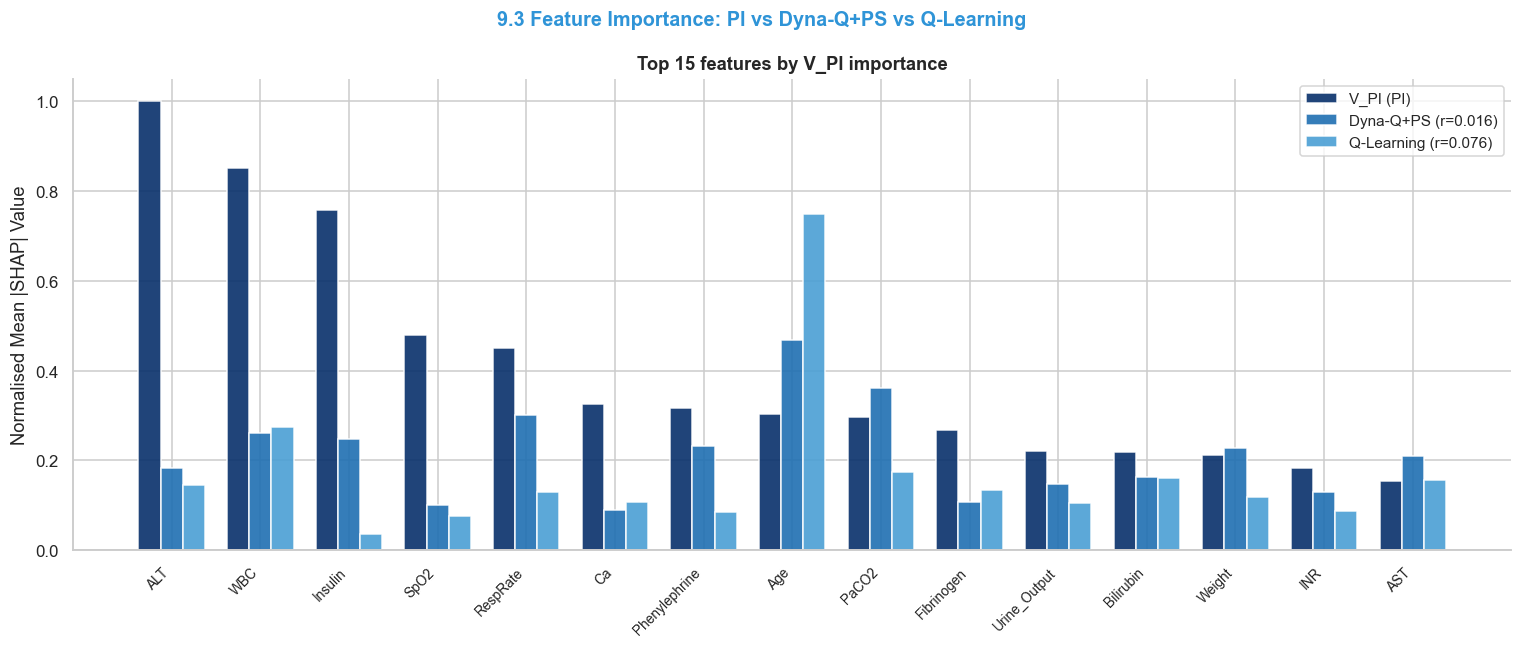


  Feature importance correlation with V_PI:
    Dyna-Q+PS  : r = 0.016
    Q-Learning : r = 0.076
  Q-Learning weights clinical features more similarly to the optimal policy.


In [60]:
imp_dq, imp_ql, r_dq, r_ql = fa.shap_comparison(
    Q_dq,
    Q_ql,
    shap_vpi_imp,
    cluster_centers,
    S - 2,
    FEATURE_NAMES,
    seed=SEED,
)